# Conditional GANs

GANs consist of two neural networks—the **generator** and the **discriminator**—which are trained together in a competitive setting. 

### 1. GAN Framework:
The basic GAN structure involves two components:

- **Generator (G)**: The generator’s job is to create fake data that is as similar as possible to the real data it is trained on. It takes random noise (a vector of random values) as input and generates an output that resembles the target data distribution (e.g., realistic images).
- **Discriminator (D)**: The discriminator’s job is to distinguish between real data (from the training set) and fake data (from the generator). It outputs a probability between 0 and 1, indicating how likely it thinks the input is real.

### 2. GAN Training:
The training process of a GAN is a min-max game between the two networks:

- The generator tries to minimize the difference between real and generated data, essentially trying to make its generated data so realistic that the discriminator cannot distinguish it from real data.
- The discriminator tries to maximize its ability to correctly identify whether an input is real or fake.

This adversarial process leads to the following setup:

- **Generator Loss**: The generator aims to fool the discriminator into thinking the generated data is real. It learns by the feedback from the discriminator.
- **Discriminator Loss**: The discriminator tries to correctly classify whether the data it receives is real or fake. Its loss function penalizes it for classifying real data as fake or generated data as real.

**Conditional GANs (cGANs)** are an extension of the original Generative Adversarial Networks (GANs), where both the generator and the discriminator are conditioned on additional information (usually labels, images, or other structured data). This added condition allows the model to generate more controlled and specific outputs, rather than generating data randomly from a distribution.

### What makes cGANs different from the original GAN?
- **Standard GAN**: The generator receives a random noise vector z as input and generates data from it.
- **Conditional GAN (cGAN)**: The generator receives both the random noise vector z and some conditional information c, which could be a label, image, or another piece of structured data.

The discriminator also receives the same condition c, alongside the data (real or fake), to decide whether the data is real or fake, given the condition.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.datasets
from torchvision.datasets import VisionDataset
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

from tqdm.notebook import tqdm

In [2]:
ds = torchvision.datasets.CelebA('.', split='train')

In [3]:
with open('./celeba/list_attr_celeba.txt') as file:
  attr_names = file.read().split('\n')[1].split()
print(f"The list of {len(attr_names)} attributes in the dataset are : \n {attr_names}")

The list of 40 attributes in the dataset are : 
 ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


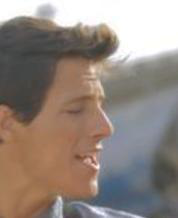

In [4]:
# Let's look at one of the sames and correspinding label
image = ds[2][0]
label = ds[2][1]
image

In [5]:
label

tensor([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1])

In [6]:
def read_label(label: torch.tensor):
  with open('./celeba/list_attr_celeba.txt') as file:
    attr_names = file.read().split('\n')[1].split()
  for idx in torch.where(label)[0]:
    print(attr_names[idx.item()])

In [7]:
read_label(ds[2][1])

Big_Lips
Blurry
Male
Narrow_Eyes
No_Beard
Pointy_Nose
Wavy_Hair
Young


In [8]:
device = torch.device("cuda")

In [9]:
# G(z) - The generator model
class GeneratorSmall(nn.Module):
    # initializers
    def __init__(self, classes, d=128, latent_size=128):
        # H_out = (H_in−1)×S−2×P+K+O_p
        super(GeneratorSmall, self).__init__()
        self.deconv1_1 = nn.ConvTranspose2d(latent_size, d*4, 4, 1, 0)
        self.deconv1_1_bn = nn.BatchNorm2d(d*4)
        self.deconv1_2 = nn.ConvTranspose2d(classes, d*4, 4, 1, 0)
        self.deconv1_2_bn = nn.BatchNorm2d(d*4)
        self.deconv2 = nn.ConvTranspose2d(d*8, d*4, 4, 2, 1)
        self.deconv2_bn = nn.BatchNorm2d(d*4)
        self.deconv3 = nn.ConvTranspose2d(d*4, d*2, 4, 2, 1)
        self.deconv3_bn = nn.BatchNorm2d(d*2)
        self.deconv4 = nn.ConvTranspose2d(d*2, d, 4, 2, 1)
        self.deconv4_bn = nn.BatchNorm2d(d)
        self.deconv5 = nn.ConvTranspose2d(d, 3, 4, 2, 1)

    # weight_init
    def weight_init(self, mean, std):
        for m in self._modules:
            normal_init(self._modules[m], mean, std)

    # forward method
    def forward(self, input, label):
        """
        Expects an input latent vector and a label of the output we want to generate
        """
        x = F.leaky_relu(self.deconv1_1_bn(self.deconv1_1(input)), 0.2)
        y = F.leaky_relu(self.deconv1_2_bn(self.deconv1_2(label)), 0.2)
        x = torch.cat([x, y], 1)
        x = F.leaky_relu(self.deconv2_bn(self.deconv2(x)), 0.2)
        x = F.leaky_relu(self.deconv3_bn(self.deconv3(x)), 0.2)
        x = F.leaky_relu(self.deconv4_bn(self.deconv4(x)), 0.2)
        x = F.sigmoid(self.deconv5(x))

        return x

In [10]:
modelG = GeneratorSmall(10).to(device)
summary(modelG, [(128, 1, 1), (10, 1, 1)])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]       1,049,088
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
   ConvTranspose2d-3            [-1, 512, 4, 4]          82,432
       BatchNorm2d-4            [-1, 512, 4, 4]           1,024
   ConvTranspose2d-5            [-1, 512, 8, 8]       8,389,120
       BatchNorm2d-6            [-1, 512, 8, 8]           1,024
   ConvTranspose2d-7          [-1, 256, 16, 16]       2,097,408
       BatchNorm2d-8          [-1, 256, 16, 16]             512
   ConvTranspose2d-9          [-1, 128, 32, 32]         524,416
      BatchNorm2d-10          [-1, 128, 32, 32]             256
  ConvTranspose2d-11            [-1, 3, 64, 64]           6,147
Total params: 12,152,451
Trainable params: 12,152,451
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Fo

In [11]:
class DiscriminatorSmall(nn.Module):
    # initializers
    def __init__(self, classes, d=128):
        super(DiscriminatorSmall, self).__init__()
        self.conv1_1 = nn.Conv2d(3, int(d/2), 4, 2, 1)
        self.conv1_2 = nn.Conv2d(classes, int(d/2), 4, 2, 1)
        self.conv2 = nn.Conv2d(d, d*2, 4, 2, 1)
        self.conv2_bn = nn.BatchNorm2d(d*2)
        self.conv3 = nn.Conv2d(d*2, d*4, 4, 2, 1)
        self.conv3_bn = nn.BatchNorm2d(d*4)
        self.conv4 = nn.Conv2d(d*4, d*8, 4, 2, 1)
        self.conv4_bn = nn.BatchNorm2d(d*8)
        self.conv5 = nn.Conv2d(d*8, 1, 4, 1, 0)

    # weight_init
    def weight_init(self, mean, std):
        for m in self._modules:
            normal_init(self._modules[m], mean, std)

    # forward method
    def forward(self, input, label):
        """
        Takes in an input image and a conditional label and decides how real it looks
        """
        x = F.leaky_relu(self.conv1_1(input), 0.2)
        y = F.leaky_relu(self.conv1_2(label), 0.2)
        x = torch.cat([x, y], 1)
        x = F.leaky_relu(self.conv2_bn(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.conv3_bn(self.conv3(x)), 0.2)
        x = F.leaky_relu(self.conv4_bn(self.conv4(x)), 0.2)
        x = F.sigmoid(self.conv5(x))

        return x

In [12]:
modelD = DiscriminatorSmall(10).to(device)
summary(modelD, [(3, 64, 64), (10, 64, 64)])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           3,136
            Conv2d-2           [-1, 64, 32, 32]          10,304
            Conv2d-3          [-1, 256, 16, 16]         524,544
       BatchNorm2d-4          [-1, 256, 16, 16]             512
            Conv2d-5            [-1, 512, 8, 8]       2,097,664
       BatchNorm2d-6            [-1, 512, 8, 8]           1,024
            Conv2d-7           [-1, 1024, 4, 4]       8,389,632
       BatchNorm2d-8           [-1, 1024, 4, 4]           2,048
            Conv2d-9              [-1, 1, 1, 1]          16,385
Total params: 11,045,249
Trainable params: 11,045,249
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 1920.00
Forward/backward pass size (MB): 2.75
Params size (MB): 42.13
Estimated Total Size (MB): 1964.88
------------------------------

In [13]:
def label_transform_fn(attrs_desired):
    """
    This function takes in a list of strings that are attributes listed in our dataset exploration
    section and returns a transform for our label. It also returns the label size

    Our dataset has 40 different attributes, but maybe we only care about controlling
    2 or 3 of them. Instead of passing in the label vector for all 40 attributes to our models,
    this transform will cut down our label so it only includes the attributes in the label we
    care about in the order specified by our input attrs_desired
    """
    with open('./celeba/list_attr_celeba.txt') as file:
        attr_names = file.read().split('\n')[1].split()

    idxs = [attr_names.index(attr) for attr in attrs_desired]

    print("Conditioning on the following attributes:")
    for i in idxs:
        print(attr_names[i])
    print("-----------------------------------------")

    return lambda x: x[idxs].float(), len(attrs_desired)

In [16]:
# For us, we will only condition on male vs female, so of our attribute names, this is the only ones we care about
# This will make our label [1,] if male and [0,] if female. Feel free to play with this if you want
# to condition on more than one label and control other things too
target_transform, label_size = label_transform_fn(["Male", "Blond_Hair"])

Conditioning on the following attributes:
Male
Blond_Hair
-----------------------------------------


In [24]:
# Training hyperparameters you can feel free to play around with
_bsize = 512
_gen_steps = 1
_disc_steps = 3
_epochs = 40
# Do not change these parameters
checkpoint_path = path = './checkpoints/'
_img_size = 64
latent_size = 128
_lr = 0.0002
betas = (.5, 0.999)

In [25]:
generator = GeneratorSmall(classes=label_size, latent_size=latent_size).to(device)
summary(generator, [(latent_size, 1, 1), (label_size, 1, 1)])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]       1,049,088
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
   ConvTranspose2d-3            [-1, 512, 4, 4]          16,896
       BatchNorm2d-4            [-1, 512, 4, 4]           1,024
   ConvTranspose2d-5            [-1, 512, 8, 8]       8,389,120
       BatchNorm2d-6            [-1, 512, 8, 8]           1,024
   ConvTranspose2d-7          [-1, 256, 16, 16]       2,097,408
       BatchNorm2d-8          [-1, 256, 16, 16]             512
   ConvTranspose2d-9          [-1, 128, 32, 32]         524,416
      BatchNorm2d-10          [-1, 128, 32, 32]             256
  ConvTranspose2d-11            [-1, 3, 64, 64]           6,147
Total params: 12,086,915
Trainable params: 12,086,915
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Fo

In [26]:
discriminator = DiscriminatorSmall(classes=label_size).to(device)
summary(discriminator, [(3, _img_size, _img_size), (label_size, _img_size, _img_size)])

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           3,136
            Conv2d-2           [-1, 64, 32, 32]           2,112
            Conv2d-3          [-1, 256, 16, 16]         524,544
       BatchNorm2d-4          [-1, 256, 16, 16]             512
            Conv2d-5            [-1, 512, 8, 8]       2,097,664
       BatchNorm2d-6            [-1, 512, 8, 8]           1,024
            Conv2d-7           [-1, 1024, 4, 4]       8,389,632
       BatchNorm2d-8           [-1, 1024, 4, 4]           2,048
            Conv2d-9              [-1, 1, 1, 1]          16,385
Total params: 11,037,057
Trainable params: 11,037,057
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 384.00
Forward/backward pass size (MB): 2.75
Params size (MB): 42.10
Estimated Total Size (MB): 428.85
--------------------------------

In [27]:
# Initialize an Adam optimizer running standard gradient descent using the above learning rate and betas for BOTH
# the generator and discriminator separately. We want to have a separate generator optimizer and discriminator optimizer
# containing the generator's params and discriminator's params separately.
optimizerG = optim.Adam(generator.parameters(), lr=_lr, betas=betas)
optimizerD = optim.Adam(discriminator.parameters(), lr=_lr, betas=betas)

In [28]:
ds = torchvision.datasets.CelebA('.',
                                 split='train',
                                 transform=torchvision.transforms.Compose([torchvision.transforms.PILToTensor(),
                                                                                               torchvision.transforms.Resize((_img_size, _img_size)),
                                                                                               lambda x: x / 256]),
                                 target_transform = target_transform)

dataloader = DataLoader(ds, batch_size=_bsize, shuffle=True)

In [29]:
def display_multiple_img(images, rows = 1, cols=1):
    figure, ax = plt.subplots(nrows=rows,ncols=cols, figsize = (40, 40))
    for ind,title in enumerate(images):
        ax.ravel()[ind].imshow((images[title][0].swapaxes(0, -1).swapaxes(0, 1) + 1) / 2)
        ax.ravel()[ind].set_title(title + ' ' + str(images[title][1]))
        ax.ravel()[ind].set_axis_off()
    plt.tight_layout()
    plt.show()

In [30]:
def training_loop(dataloader, label_size, latent_size, b_size, img_size, epochs, generator, discriminator, 
                  optimizerG, optimizerD, show_after_epoch = True,
                  checkpoint_directory = "./checkpoints/", exp_name = None, gen_steps = 2,
                  disc_steps = 1, epoch_start = 0, max_train_steps_per_epoch = -1):

    criterion = nn.BCELoss()
    generator_history = []
    discriminator_history = []
    #Actual training loop
    for epoch in range(epoch_start, epoch_start + epochs):
        batch = tqdm(enumerate(dataloader), desc = "Epoch " + str(epoch), total = (min(len(ds)//b_size, max_train_steps_per_epoch) if max_train_steps_per_epoch > 0 else len(ds)//b_size))

        #not sure what this is, but evan had it in his code
        if epoch == 5 or epoch == 10:
            optimizerG.param_groups[0]['lr'] /= 10
            optimizerD.param_groups[0]['lr'] /= 10

        for i, (images, labels) in batch:
            images = images.to(device)     # b_size, 3, 64, 64

            batch_size = images.shape[0]
            """
            We need target labels to feed into our classification loss.
            We need a tensor of shape (batch_size,) of ones and another tensor
            of the same shape but filled with zeros. 
            This is because the discriminator wants target values of all 1's on real images
            and target values of all 0's on fake images, so we need to use these as our targets
            in our classification loss later on
            """
            y_real = torch.ones((batch_size,)).to(device).to(torch.float).squeeze() # Classify real images as 1
            y_fake = torch.zeros((batch_size,)).to(device).to(torch.float).squeeze() # Classify fake images as 0


            # These are the true conditional labels for this batch of data and we
            # will be using these labels for both our generator and discriminator
            # These are the same numbers, just different shapes since our generator and discriminator
            # expect these specific shapes as input
            g_labels = labels.unsqueeze(-1).unsqueeze(-1).to(device)                          # b_size, label_size, 1, 1 
            d_labels = g_labels.broadcast_to((batch_size, label_size, img_size, img_size))    # b_size, 1, 64, 64


            #----------------------------

            #Discriminator training
            disc_losses = []
            disc_accuracies = []
            for i in range(disc_steps):
                # Zero the discriminator gradients
                discriminator.zero_grad()
                #get the loss on real images (and metrics)
                """
                1. Call the discriminator on the images we got at the start of this train step and the
                conditional labels we made specifically for our descriminator (d_labels)
                2. Call our loss (criterion) on our discriminator's output on real images and the target (y)
                values for real images that you defined earlier
                """
                D_out_real = discriminator(images, d_labels).squeeze()
                D_loss_real = criterion(D_out_real, y_real)
                real_accuracy = torch.mean(1 - torch.abs(D_out_real - y_real)).item()

                #get the loss on fake images (and metrics)
                """
                1. Make a gaussian random noise vector of size (batch_size, latent_size, 1, 1)
                2. Feed this noise (our latent vector) and conditional labels we made specifically for our generator
                into the generator
                """
                noise = torch.randn((batch_size, latent_size, 1, 1)).to(device)     # b_size, 128, 1, 1
                gen_image = generator(noise, g_labels)                              # gen_image = b_size, 3, 64, 64

                """
                1. Call discriminator on the generated images and the discriminator labels we made
                2. Call our loss function on discriminators outputs and target labels (y) of fake
                """
                D_out_fake = discriminator(gen_image, d_labels).squeeze()
                D_loss_fake = criterion(D_out_fake, y_fake)
                fake_accuracy = torch.mean(1 - torch.abs(D_out_fake - y_fake)).item()

                #add real and fake losses and backpropogate and step the discriminator's optimizer
                D_loss = D_loss_real + D_loss_fake
                D_loss.backward()
                optimizerD.step()

                #recording for metrics
                disc_losses.append(D_loss.item())
                disc_accuracies.append((real_accuracy, fake_accuracy))

            #Generator training
            gen_losses = []
            for i in range(gen_steps):
                generator.zero_grad()

                #get discriminator predictions on faked images, and take loss between real y
                """
                1. Create another noise vector of the same shape (batch_size, latent_size, 1, 1)
                2. Pass this and the generator's conditional labels into the generator
                """
                noise = torch.randn((batch_size, latent_size, 1, 1)).to(device)
                gen_image = generator(noise, g_labels)

                """
                1. Pass generated image and discriminator's conditional labels into discriminator
                2. Get the classification loss on discriminators output and REAL target (y) value
                  - The reason for these being labeled as "real" is we are doing the non-saturating loss which amounts to
                    the generator wanting to get our labels to be equal to 1 on the same binary cross entropy loss.
                  - This gradient here will only effect the generator, hence why we can do this
                """
                D_out_gen = discriminator(gen_image, d_labels).squeeze()
                gen_loss = criterion(D_out_gen, y_real)

                #backprop and step the generator's optimizer
                gen_loss.backward()
                optimizerG.step()

                gen_losses.append(gen_loss.item())

            batch.set_postfix({'Disc loss': torch.mean(torch.tensor(disc_losses[-disc_steps:])).item(),
                  'Gen loss': torch.mean(torch.tensor(gen_losses[-disc_steps:])).item(),
                  'Disc Real Accuracy': torch.mean(torch.tensor([disc_accuracies[-i-1][0] for i in range(disc_steps)])).item(),
                  'Disc Fake Accuracy': torch.mean(torch.tensor([disc_accuracies[-i-1][1] for i in range(disc_steps)])).item()})

            #append losses to the histories
            generator_history.append(gen_losses)
            discriminator_history.append(disc_losses)

        #printing some outputs
        if show_after_epoch:
            _, labels = next(iter(dataloader))
            batch_size = labels.shape[0]
            g_labels = labels.unsqueeze(-1).unsqueeze(-1).to(device)
            noise = torch.randn(batch_size, latent_size, device = device).view(-1, latent_size, 1, 1)
            gen_image = generator(noise, g_labels)
            images = [gen_image[i].squeeze().to('cpu').detach() for i in range(min(batch_size, 8))]
            labels = [labels[i].squeeze().to('cpu').detach() for i in range(min(batch_size, 8))]
            images = {'Image'+str(i): [image.numpy(), label.numpy()] for i, (image, label) in enumerate(zip(images, labels))}
            display_multiple_img(images, min(batch_size, 8), 1)

        #checkpointing the GAN
        if checkpoint_directory:
            if not exp_name:
                exp_name = 'unnamed'
            torch.save({
                        'generator_losses': generator_history,
                        'discriminator_losses': discriminator_history,
                        'epoch': epoch,
                        'generator_state_dict': generator.state_dict(),
                        'discriminator_state_dict': discriminator.state_dict(),
                        'generator_optimizer_state_dict': optimizerG.state_dict(),
                        'discriminator_optimizer_state_dict': optimizerD.state_dict(),
                        }, checkpoint_directory + '/' + exp_name + '_' + str(epoch) + '.pt')


    #return generator_history, discriminator_history


In [31]:
training_loop(dataloader, label_size, latent_size, _bsize, _img_size, _epochs, generator, discriminator, optimizerG, optimizerD, False,
                  checkpoint_path, None, _gen_steps, _disc_steps, epoch_start = 0, max_train_steps_per_epoch=-1)

Epoch 0:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/317 [00:00<?, ?it/s]

...

Epoch 35:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 36:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 37:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 38:   0%|          | 0/317 [00:00<?, ?it/s]

Epoch 39:   0%|          | 0/317 [00:00<?, ?it/s]

# Eval
Finally, let's load the generator and discriminator and see how they perform on the test dataset.

In [63]:
path = './checkpoints/unnamed_39.pt'
label_size = 2
generator = GeneratorSmall(classes=label_size, latent_size=128)
latent_size = 128
ds_test = torchvision.datasets.CelebA('.',
                                 split='test',
                                 transform=torchvision.transforms.Compose([torchvision.transforms.PILToTensor(),
                                                                                               torchvision.transforms.Resize((_img_size, _img_size)),
                                                                                               lambda x: x / 256]),
                                 target_transform = target_transform)


In [73]:
batch_size = 24
data_loader_test = DataLoader(ds_test, batch_size=batch_size, shuffle=True)
test_data_iter = iter(data_loader_test)
test_features, test_labels = next(test_data_iter)

In [74]:
def display_final(images, rows = 1, cols=1):
    figure, ax = plt.subplots(nrows=rows,ncols=cols, figsize = (40, 40))
    for ind,title in enumerate(images):
        ax.ravel()[ind].imshow((images[title][0].swapaxes(0, -1).swapaxes(0, 1) + 1) / 2)
        ax.ravel()[ind].set_title(title + ' ' + str(images[title][1]), {'fontsize': 25})
        ax.ravel()[ind].set_axis_off()
    plt.tight_layout()
    plt.show()

In [75]:
generator.load_state_dict(torch.load(path)['generator_state_dict'])
generator.eval()

GeneratorSmall(
  (deconv1_1): ConvTranspose2d(128, 512, kernel_size=(4, 4), stride=(1, 1))
  (deconv1_1_bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv1_2): ConvTranspose2d(2, 512, kernel_size=(4, 4), stride=(1, 1))
  (deconv1_2_bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv2): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv2_bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv3_bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv4): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv4_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (deconv5): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), pa

In [76]:
labels = torch.tensor(test_labels).unsqueeze(-1).unsqueeze(-1).float() # 16, 2, 1, 1
noise = torch.randn(batch_size, latent_size, 1, 1)
gen_image = generator(noise, labels)    # 16, 3, 64, 64

/tmp/ipykernel_13367/2933086031.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(test_labels).unsqueeze(-1).unsqueeze(-1).float() # 16, 2, 1, 1


In [77]:
images = [gen_image[i].squeeze().to('cpu').detach() for i in range(batch_size)]
labels = [labels[i].squeeze().to('cpu').detach() for i in range(batch_size)]
images = {'Image'+str(i): [image.numpy(), label.numpy()] for i, (image, label) in enumerate(zip(images, labels))}

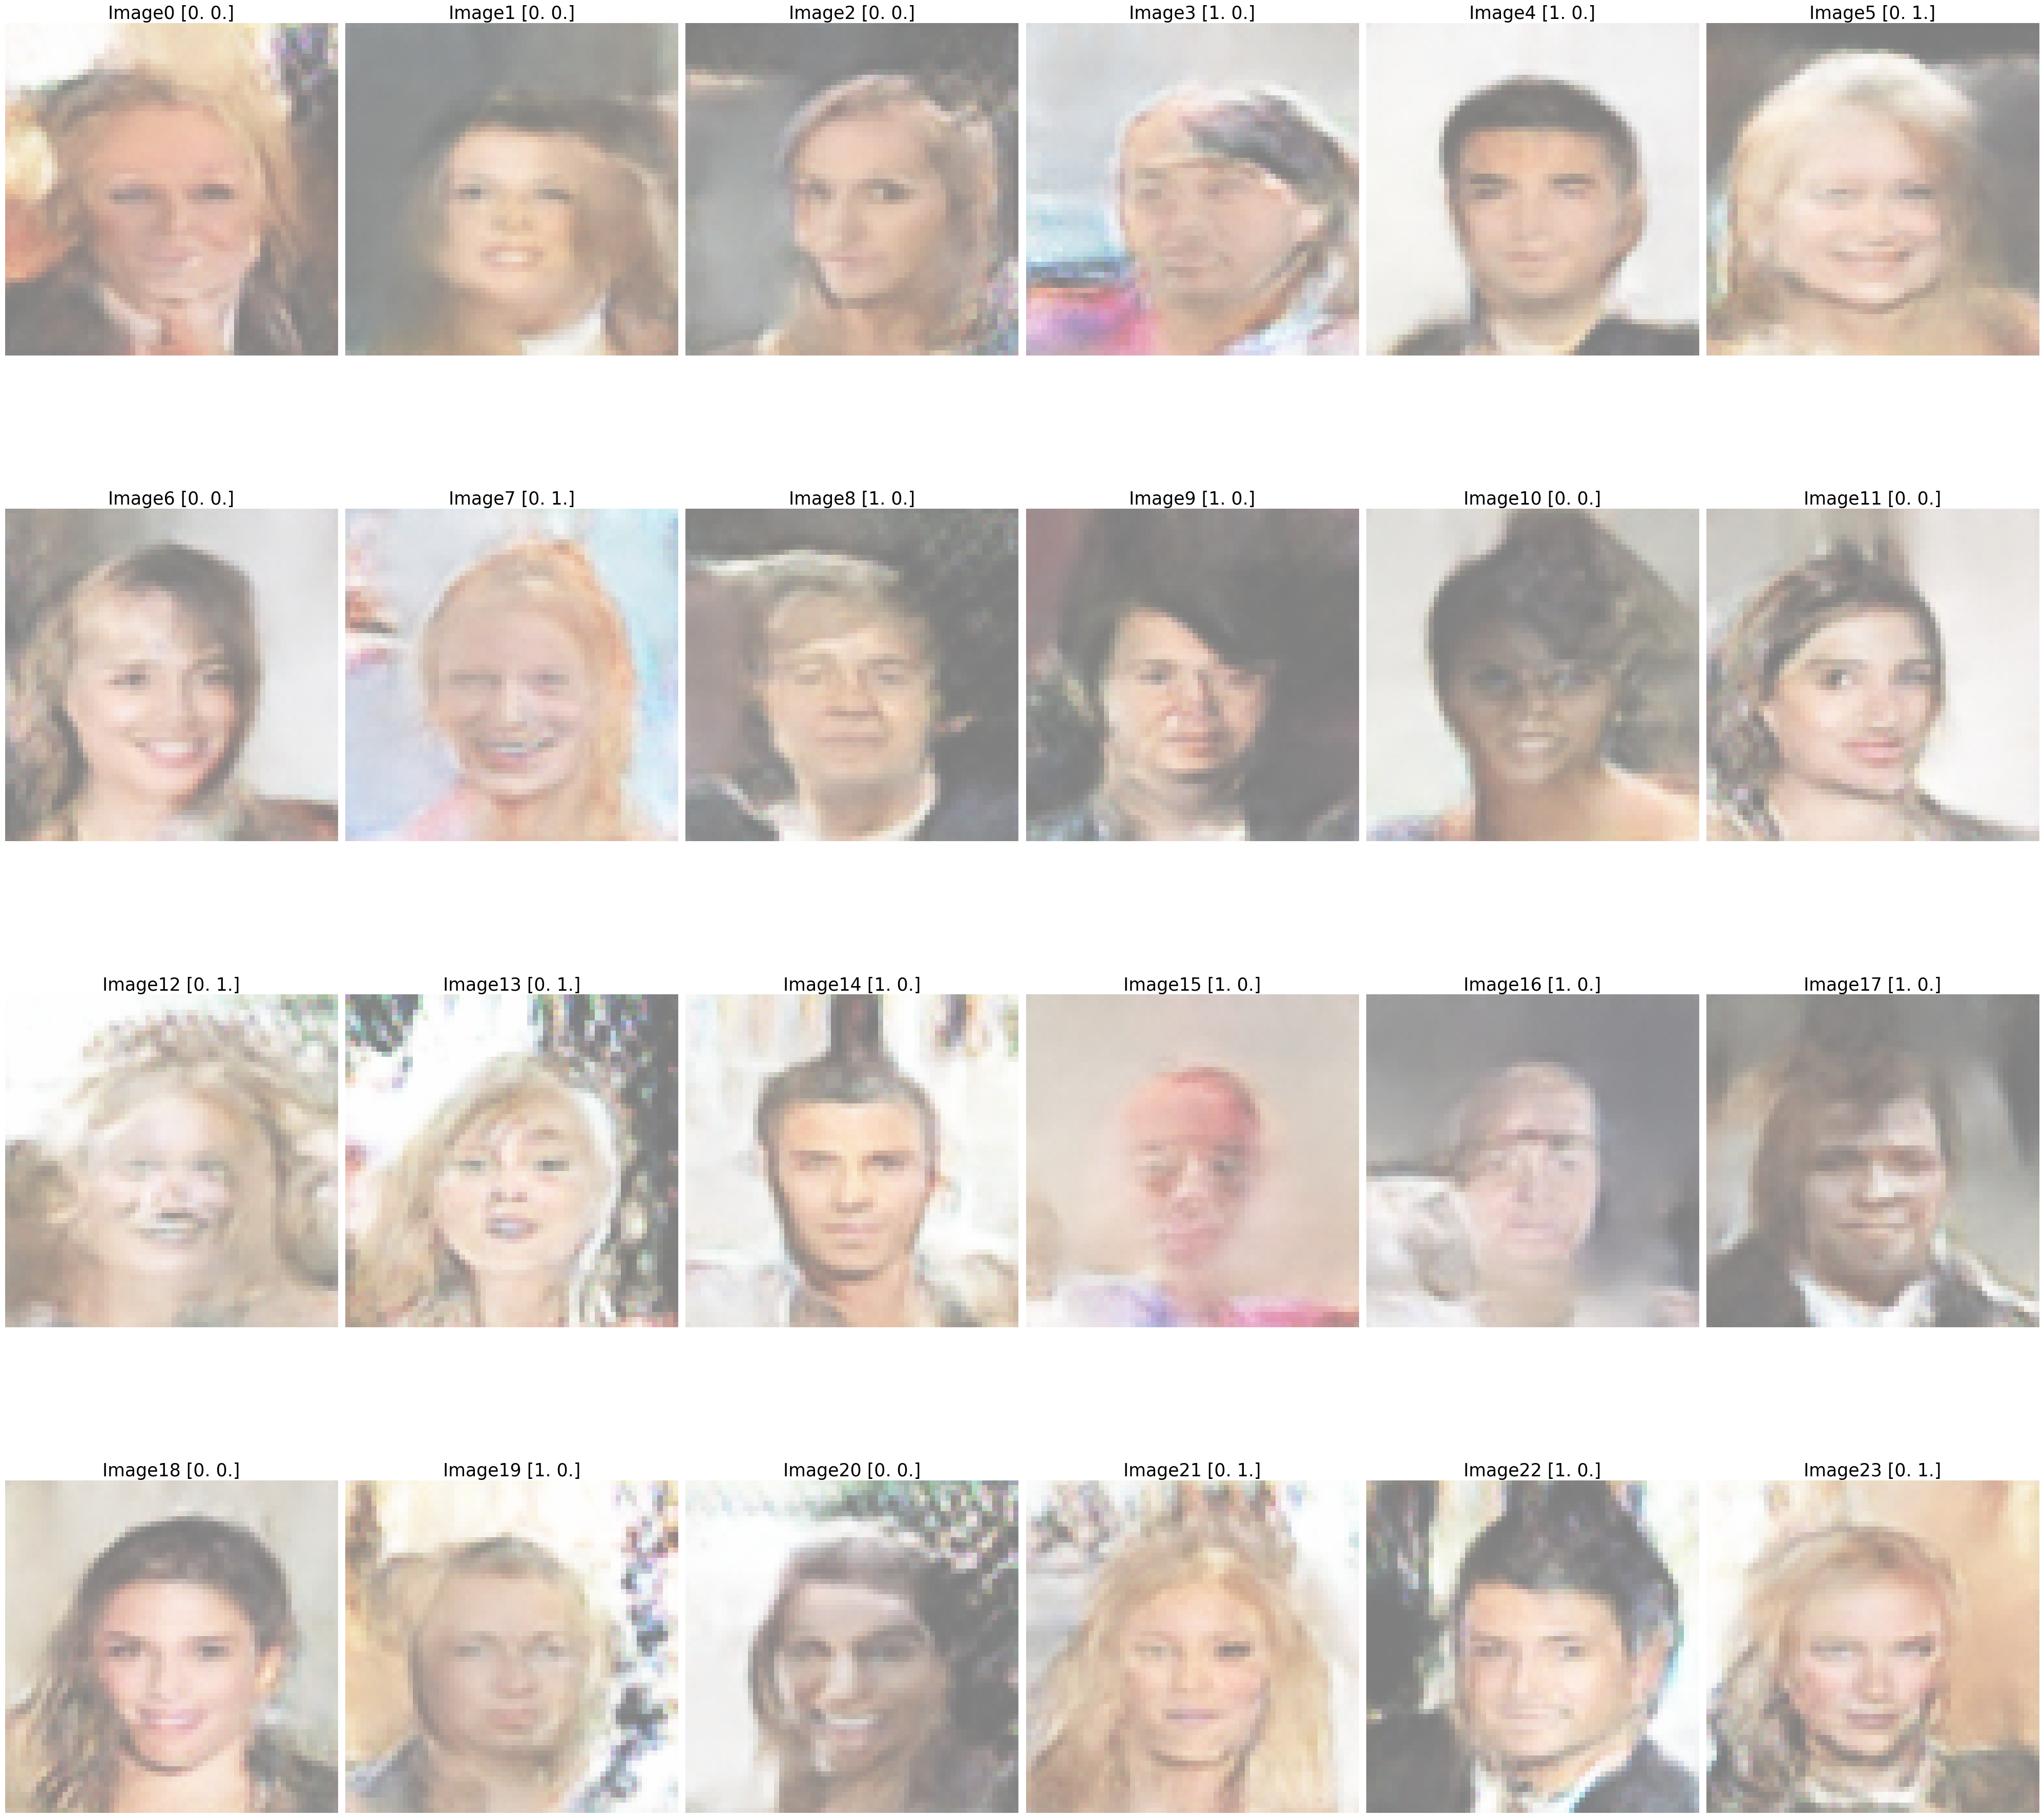

In [78]:
display_final(images, 4, 6)

In the above images, we can see where ever we have male and/or blonde hair the bit is set.